In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df = pd.read_csv("../data/neurosense_cleaned.csv")

X = df.drop(columns=["label", "subject", "session", "trial", "sample"])
X = X.select_dtypes(include=["number"])

y = df["label"]
groups = df["subject"]

print("Dataset shape:", df.shape)
print("Features:", X.shape[1])
print("Classes:", sorted(y.unique()))

Dataset shape: (37575, 361)
Features: 355
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [3]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train subjects:", df.iloc[train_idx]["subject"].nunique())
print("Test subjects:", df.iloc[test_idx]["subject"].nunique())

Train shape: (30060, 355)
Test shape: (7515, 355)
Train subjects: 12
Test subjects: 3


In [4]:
#Arkitektura 1: MLP me 1 hidden layer
mlp_arch1 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=50, random_state=42)),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64,),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=42
    ))
])

mlp_arch1.fit(X_train, y_train)
y_pred_arch1 = mlp_arch1.predict(X_test)

arch1_results = {
    "Model": "MLP Architecture 1 PCA50",
    "Accuracy": accuracy_score(y_test, y_pred_arch1),
    "Precision": precision_score(y_test, y_pred_arch1, average="weighted"),
    "Recall": recall_score(y_test, y_pred_arch1, average="weighted"),
    "F1-score": f1_score(y_test, y_pred_arch1, average="weighted"),
    "Architecture": "(64,), relu"
}

arch1_results

{'Model': 'MLP Architecture 1 PCA50',
 'Accuracy': 0.3393213572854291,
 'Precision': 0.34672347401547765,
 'Recall': 0.3393213572854291,
 'F1-score': 0.3239283016038906,
 'Architecture': '(64,), relu'}

In [5]:
#Arkitektura 2: MLP me 2 hidden layers
mlp_arch2 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=50, random_state=42)),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=42
    ))
])

mlp_arch2.fit(X_train, y_train)
y_pred_arch2 = mlp_arch2.predict(X_test)

arch2_results = {
    "Model": "MLP Architecture 2 PCA50",
    "Accuracy": accuracy_score(y_test, y_pred_arch2),
    "Precision": precision_score(y_test, y_pred_arch2, average="weighted"),
    "Recall": recall_score(y_test, y_pred_arch2, average="weighted"),
    "F1-score": f1_score(y_test, y_pred_arch2, average="weighted"),
    "Architecture": "(128,64), relu"
}

arch2_results

{'Model': 'MLP Architecture 2 PCA50',
 'Accuracy': 0.33506320691949437,
 'Precision': 0.3596560430260311,
 'Recall': 0.33506320691949437,
 'F1-score': 0.33693945988437923,
 'Architecture': '(128,64), relu'}

In [6]:
#Hyperparameter tuning për MLP
mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=42)),
    ("mlp", MLPClassifier(
        solver="adam",
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=42
    ))
])

param_grid = {
    "pca__n_components": [20, 50, 100],
    "mlp__hidden_layer_sizes": [(64,), (128,), (128, 64)],
    "mlp__activation": ["relu", "tanh"],
    "mlp__alpha": [0.0001, 0.001, 0.01],
    "mlp__learning_rate_init": [0.001, 0.0005]
}

grid_mlp = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_mlp.fit(X_train, y_train)

print("Best Parameters:")
print(grid_mlp.best_params_)

print("Best CV F1-score:")
print(grid_mlp.best_score_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Parameters:
{'mlp__activation': 'relu', 'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (64,), 'mlp__learning_rate_init': 0.0005, 'pca__n_components': 20}
Best CV F1-score:
0.2860285213101601


In [7]:
best_mlp = grid_mlp.best_estimator_

y_pred_tuned = best_mlp.predict(X_test)

tuned_results = {
    "Model": "MLP Tuned PCA GroupSplit 4-Class",
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned, average="weighted"),
    "Recall": recall_score(y_test, y_pred_tuned, average="weighted"),
    "F1-score": f1_score(y_test, y_pred_tuned, average="weighted"),
    "Architecture": grid_mlp.best_params_
}

tuned_results

{'Model': 'MLP Tuned PCA GroupSplit 4-Class',
 'Accuracy': 0.3069860279441118,
 'Precision': 0.3207290058847563,
 'Recall': 0.3069860279441118,
 'F1-score': 0.2993738992064338,
 'Architecture': {'mlp__activation': 'relu',
  'mlp__alpha': 0.001,
  'mlp__hidden_layer_sizes': (64,),
  'mlp__learning_rate_init': 0.0005,
  'pca__n_components': 20}}

              precision    recall  f1-score   support

           0       0.35      0.47      0.40      1950
           1       0.24      0.32      0.27      1905
           2       0.31      0.25      0.28      1947
           3       0.39      0.17      0.24      1713

    accuracy                           0.31      7515
   macro avg       0.32      0.30      0.30      7515
weighted avg       0.32      0.31      0.30      7515



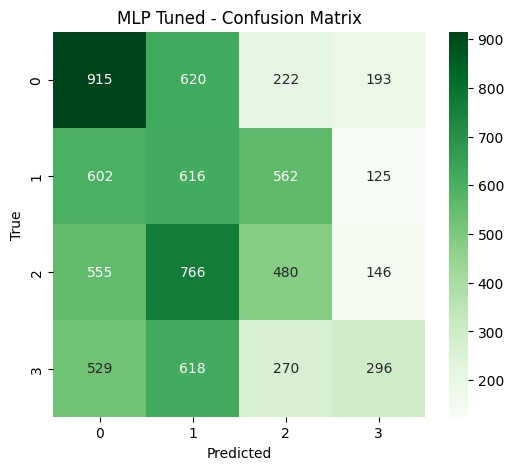

In [8]:
#Classification report + confusion matrix
print(classification_report(y_test, y_pred_tuned))

cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("MLP Tuned - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [9]:
mlp_comparison = pd.DataFrame([
    arch1_results,
    arch2_results,
    tuned_results
])

mlp_comparison
mlp_comparison.to_csv(
    "../results/tables/mlp_neural_network_results.csv",
    index=False
)